In [1]:
# Install required libraries (ensure you are using a GPU runtime for training!)
!pip install roboflow ultralytics pandas matplotlib opencv-python-headless seaborn
!pip install protobuf==3.20.3 # Fixes potential Protobuf version conflicts

import os
import cv2
import glob
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import display, Image # For displaying saved plots

# --- 🎯 CRITICAL USER CONFIGURATION ---
# 1. Image Scaling Reference
# Enter the physical width of the entire image capture area (or a known reference object) in inches.
KNOWN_REFERENCE_WIDTH_INCHES = 18.0

# 2. QC Thresholds (Based on your engineering and historical data)
# These are used for the final Pass/Fail decision
QC_MIN_WIDTH_IN = 0.30        # Minimum allowed QBlock width (e.g., must not shrink below 0.3in)
QC_MAX_BRIGHTNESS = 150       # Maximum average brightness (higher is more faded/lighter)
EXPECTED_QBLOCK_COUNT = 14    # Target number of blocks per ticket

# 3. Model Classes
CORRECT_CLASS = "qblock"
INCORRECT_CLASS = "incorrect qblock" # The target class for faded/poor quality blocks
CONFIDENCE_THRESHOLD = 0.5
IGNORED_CLASSES = {
    "backgroundclutter", "smallqblock", "faded-qblock", "faded-smallqblock"
}
# ------------------------------------------

# --- Roboflow Download and Path Setup ---
print("--- 🛠️ Phase 1: Setup and Data Download ---")

# Execute your Roboflow download
# Note: Using your provided API key and project
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
# Note: Using version 23 from your last code snippet
version = project.version(23)
dataset = version.download("yolov8")

# Dynamically set paths
dataset_root_path = dataset.location
config_path = os.path.join(dataset_root_path, 'data.yaml')
print(f"YOLOv8 Config Path: {config_path}")

# --- Load YAML to get Class IDs ---
def load_class_map(config_path):
    with open(config_path, "r") as f:
        data = yaml.safe_load(f)

    names = data["names"]
    if isinstance(names, list):
        return {name: idx for idx, name in enumerate(names)}
    elif isinstance(names, dict):
        return {v: k for k, v in names.items()}

    raise ValueError("Invalid 'names:' format in YAML.")

class_map = load_class_map(config_path)
correct_id = class_map[CORRECT_CLASS]
incorrect_id = class_map[INCORRECT_CLASS]
ignored_ids = {class_map[name] for name in IGNORED_CLASSES if name in class_map}

print("\nClass Map:", class_map)
print(f"Correct block class ID: {correct_id}")
print(f"Incorrect block class ID: {incorrect_id}")
print(f"Ignored class IDs: {ignored_ids}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
  

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- 🛠️ Phase 1: Setup and Data Download ---
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eagle-eyes-23 in yolov8:: 100%|██████████| 6396/6396 [00:01<00:00, 4557.23it/s]

YOLOv8 Config Path: /content/eagle-eyes-23/data.yaml

Class Map: {'backgroundclutter': 0, 'faded-qblock': 1, 'faded-smallqblock': 2, 'incorrect qblock': 3, 'qblock': 4, 'smallqblock': 5}
Correct block class ID: 4
Incorrect block class ID: 3
Ignored class IDs: {0, 1, 2, 5}


In [2]:
# --- 🧠 Phase 2: Training YOLOv8 Model ---
print("\n--- 🧠 Phase 2: Training YOLOv8 Model ---")
print("Loading pre-trained YOLOv8n model...")

try:
    model = YOLO('yolov8n.pt')

    # Train the Model
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10, # Reduced to 10 for quick testing; use 50+ for production accuracy
        imgsz=640,
        batch=-1,
        name='yolov8n_qc_detector'
    )

    print("\n--- Training complete! ---")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')

except Exception as e:
    print(f"FATAL ERROR during training. Error: {e}")
    best_model_path = None


--- 🧠 Phase 2: Training YOLOv8 Model ---
Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

In [7]:
# --- UTILITY FUNCTIONS ---

# 1. Color Extraction (Updated from previous steps)
def get_avg_color_and_hex(img_array, xmin, ymin, xmax, ymax):
    """Calculates the average color (RGB) and Hex code for a detected bounding box."""
    h, w = img_array.shape[:2]
    xmin, ymin = max(0, xmin), max(0, ymin)
    xmax, ymax = min(w, xmax), min(h, ymax)

    cropped_img = img_array[ymin:ymax, xmin:xmax]

    if cropped_img.size == 0:
        # Return zeros if crop failed
        return 0, 0, 0, '#000000', 0

    avg_color = cv2.mean(cropped_img)[:3]
    b, g, r = avg_color

    hex_color = '#%02x%02x%02x' % (int(r), int(g), int(b))
    avg_brightness = (int(r) + int(g) + int(b)) / 3 # Simple fading metric

    return int(r), int(g), int(b), hex_color, avg_brightness

# 2. Dimension Extraction (Updated and simplified)
def get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, ref_width_in):
    """Calculates QBlock dimensions in inches using the PPM scaling factor."""
    if img_width == 0:
        return 0.0, 0.0

    PPM = img_width / ref_width_in

    width_pixels = xmax - xmin
    height_pixels = ymax - ymin

    width_inches = width_pixels / PPM
    height_inches = height_pixels / PPM

    return round(width_inches, 4), round(height_inches, 4)

# 3. Image-Level QC Rule
def classify_image(correct_count, incorrect_count):
    """Determines basic Pass/Fail based on block count."""
    if correct_count >= EXPECTED_QBLOCK_COUNT and incorrect_count == 0:
        return "PASS_COUNT"
    return "FAIL_COUNT"

In [8]:
# --- 📏 Phase 3: Inference and Integrated Data Collection ---

if not os.path.exists(best_model_path):
    print(f"FATAL ERROR: Trained weights not found at {best_model_path}. Please re-run Cell 2.")
else:
    print("\n=== Loading best model for inference ===")
    model = YOLO(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")

    # Load test images
    test_dir = os.path.join(dataset_root_path, "test", "images")
    test_images = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        test_images.extend(glob.glob(os.path.join(test_dir, ext)))
    print(f"Found {len(test_images)} test images for inference.")

    # Storage for all block data
    all_blocks = []
    all_image_results = []

    print("\n=== Running inference and extracting features ===")

    # Run batch prediction for speed
    results = model.predict(
        source=test_images,
        conf=CONFIDENCE_THRESHOLD,
        save=False,
        verbose=False,
        classes=[correct_id, incorrect_id] # Only detect the classes we care about for QC
    )

    for img_path, result in zip(test_images, results):
        img_name = os.path.basename(img_path)
        img = cv2.imread(img_path)

        if img is None: continue
        (img_height, img_width) = img.shape[:2]

        # Ground truth from filename
        ground_truth = "GOOD" if "_OK" in img_name.upper() else "NOT_GOOD" if "_NG" in img_name.upper() else "UNKNOWN"

        correct_count = 0
        incorrect_count = 0

        # -----------------------------
        # PROCESS DETECTIONS
        # -----------------------------
        for i, box in enumerate(result.boxes):
            class_id = int(box.cls.cpu().item())

            if class_id == correct_id:
                correct_count += 1
            elif class_id == incorrect_id:
                incorrect_count += 1

            xmin, ymin, xmax, ymax = box.xyxy[0].cpu().numpy().astype(int)

            # Extract Color Features
            r, g, b, hex_color, brightness = get_avg_color_and_hex(img, xmin, ymin, xmax, ymax)

            # Extract Dimensional Features
            width_in, height_in = get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, KNOWN_REFERENCE_WIDTH_INCHES)

            # Store Block-level data
            all_blocks.append({
                "image_name": img_name,
                "class_name": result.names[class_id],
                "block_index": i,
                "r": r, "g": g, "b": b,
                "Brightness": brightness,
                "Width_in": width_in,
                "Height_in": height_in,
                "Confidence": round(float(box.conf.cpu().item()), 4)
            })

        # Store Image-level summary
        all_image_results.append({
            "image_name": img_name,
            "ground_truth": ground_truth,
            "correct_count": correct_count,
            "incorrect_count": incorrect_count
        })

    # Create final DataFrames
    df_blocks = pd.DataFrame(all_blocks)
    df_images = pd.DataFrame(all_image_results)

    # Save CSV of all block-level data
    results_dir = "results_qc_pipeline"
    os.makedirs(results_dir, exist_ok=True)
    block_output_path = os.path.join(results_dir, "master_block_data_qc.csv")
    df_blocks.to_csv(block_output_path, index=False)
    print(f"\nSaved master block-level data: {block_output_path}")


=== Loading best model for inference ===
Successfully loaded model from: /content/runs/detect/yolov8n_qc_detector/weights/best.pt
Found 138 test images for inference.

=== Running inference and extracting features ===

Saved master block-level data: results_qc_pipeline/master_block_data_qc.csv



=== Final QC Model Accuracy ===
Total Test Images Scored: 132
Correct Predictions:    117
QC Model Accuracy:        88.64%

--- Final QC Summary Table (First 10 Images) ---


invalid escape sequence '\D'
invalid escape sequence '\D'
invalid escape sequence '\D'


,image_name,ground_truth,QC_PREDICTION,Avg_Width,Max_Brightness,Max_Delta_E
0,251010_070153_0000043479_CAM1_NG_bmp.rf.b159a4...,NOT_GOOD,FAIL_QUALITY,0.358393,118.0,60.621778
1,251010_070154_0000043483_CAM1_NG_bmp.rf.b463bc...,NOT_GOOD,FAIL_QUALITY,0.361731,120.0,64.085880
2,251010_070157_0000043494_CAM1_NG_bmp.rf.0dec38...,NOT_GOOD,FAIL_COUNT,0.369375,93.0,17.320508
3,251010_070204_0000043517_CAM1_NG_bmp.rf.1011e3...,NOT_GOOD,FAIL_COUNT,0.369375,90.0,22.516660
4,251010_070207_0000043528_CAM1_NG_bmp.rf.7ab161...,NOT_GOOD,FAIL_COUNT,0.367500,98.0,25.980762
5,251010_070211_0000043540_CAM1_NG_bmp.rf.b37d5c...,NOT_GOOD,FAIL_COUNT,0.372273,94.0,19.052559
6,251010_070214_0000043550_CAM1_NG_bmp.rf.537429...,NOT_GOOD,FAIL_COUNT,0.368182,93.0,27.712813
7,251010_070220_0000043571_CAM1_NG_bmp.rf.bbb631...,NOT_GOOD,FAIL_COUNT,0.367500,89.0,25.980762
8,251010_070221_0000043575_CAM1_NG_bmp.rf.7ac5f1...,NOT_GOOD,FAIL_COUNT,0.367500,92.0,15.588457
9,251010_070221_0000043576_CAM1_NG_bmp.rf.f9407d...,NOT_GOOD,FAIL_COUNT,0.369375,100.0,32.908965



Saved final QC summary to: results_qc_pipeline/final_qc_summary.csv


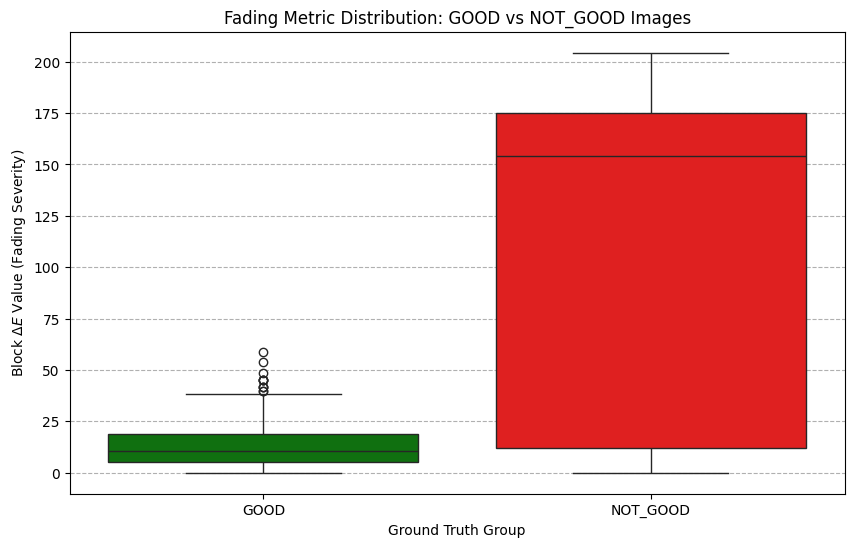

In [10]:
# --- 📊 Phase 4: Analysis and Final QC Summary ---
# if df_blocks.empty:
#     print("\nFATAL ERROR: No block data collected. Cannot run analysis.")
# else:
#     # 1. --- Compute Color Delta E Baseline ---
#     # Find the average color of the 'qblock' (correct) class to set the reference
#     correct_df = df_blocks[df_blocks["class_name"] == CORRECT_CLASS]
#     if not correct_df.empty:
#         ref_r = correct_df['r'].median()
#         ref_g = correct_df['g'].median()
#         ref_b = correct_df['b'].median()
#     else:
#         # Fallback if no correct blocks are found
#         ref_r, ref_g, ref_b = 255, 255, 255

#     # Calculate Total Delta E (fading metric) for every block relative to the median 'qblock'
#     df_blocks['Delta_E'] = np.sqrt(
#         (df_blocks['r'] - ref_r)**2 +
#         (df_blocks['g'] - ref_g)**2 +
#         (df_blocks['b'] - ref_b)**2
#     )

#     # 2. --- Aggregate Block Data to Image Level (for Final Decision) ---
#     qc_summary_df = df_blocks.groupby('filename').agg(
#         Block_Count=('filename', 'size'),
#         Correct_Count=('class_name', lambda x: (x == CORRECT_CLASS).sum()),
#         Incorrect_Count=('class_name', lambda x: (x == INCORRECT_CLASS).sum()),
#         Avg_Width=('Width_in', 'mean'),
#         Std_Width=('Width_in', 'std'),
#         Max_Brightness=('Brightness', 'max'),
#         Max_Delta_E=('Delta_E', 'max')
#     ).reset_index()

#     # Merge with the ground truth data
#     qc_summary_df = pd.merge(qc_summary_df, df_images[['image_name', 'ground_truth']],
#                              left_on='filename', right_on='image_name', how='left')


#     # 3. --- Combined Predictive QC Decision ---
#     def check_qc_criteria(row):
#         """Applies combined dimension, color, and count criteria."""

#         # 1. Count Check (missing blocks)
#         if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT:
#             return 'FAIL_COUNT'

#         # 2. Dimension Check (too small/misaligned)
#         if row['Avg_Width'] < QC_MIN_WIDTH_IN:
#             return 'FAIL_DIMENSION'

#         # 3. Color Check (too faded/too bright)
#         if row['Max_Brightness'] > QC_MAX_BRIGHTNESS:
#             return 'FAIL_COLOR'

#         return 'PASS'

#     # Apply the QC function
#     qc_summary_df['QC_PREDICTION'] = qc_summary_df.apply(check_qc_criteria, axis=1)

#     # 4. --- Summarize Accuracy ---
#     qc_summary_df['MATCH'] = (
#         (qc_summary_df['QC_PREDICTION'] == 'PASS') & (qc_summary_df['ground_truth'] == 'GOOD') |
#         (qc_summary_df['QC_PREDICTION'] != 'PASS') & (qc_summary_df['ground_truth'] == 'NOT_GOOD')
#     )

#     correct_predictions = qc_summary_df['MATCH'].sum()
#     total_scorable = len(qc_summary_df[qc_summary_df['ground_truth'] != 'UNKNOWN'])

#     print("\n=== Final QC Model Accuracy ===")
#     print(f"Total Test Images Scored: {total_scorable}")
#     print(f"Correct Predictions:    {correct_predictions}")
#     if total_scorable > 0:
#         accuracy = (correct_predictions / total_scorable) * 100
#         print(f"QC Model Accuracy:        {accuracy:.2f}%")

#     print("\n--- Final QC Summary Table (First 10 Images) ---")
#     display(qc_summary_df[['filename', 'ground_truth', 'QC_PREDICTION', 'Avg_Width', 'Max_Brightness']].head(10))

#     # Save final results
#     summary_output_path = os.path.join(results_dir, "final_qc_summary.csv")
#     qc_summary_df.to_csv(summary_output_path, index=False)
#     print(f"\nSaved final QC summary to: {summary_output_path}")

#     # 5. --- Trend Visualization (Box Plot is best for OK vs NG distribution) ---
#     plt.figure(figsize=(10, 6))

#     # Compare the distribution of the Max Delta E (worst fading) for GOOD vs NOT_GOOD images
#     plot_df = pd.merge(df_blocks, df_images[['image_name', 'ground_truth']], on='image_name')
#     sns.boxplot(x='ground_truth', y='Delta_E', data=plot_df, palette={'GOOD': 'green', 'NOT_GOOD': 'red'})

#     plt.xlabel("Ground Truth Group")
#     plt.ylabel("Block Max $\Delta E$ Value (Fading Severity)")
#     plt.title("Fading Metric Distribution: GOOD vs NOT_GOOD Images")
#     plt.grid(axis='y', linestyle='--')
#     plt.show()
if df_blocks.empty:
    print("\nFATAL ERROR: No block data collected. Cannot run analysis.")
else:
    # 1. --- Compute Color Delta E Baseline ---
    # Find the average color of the 'qblock' (correct) class to set the reference
    correct_df = df_blocks[df_blocks["class_name"] == CORRECT_CLASS]
    if not correct_df.empty:
        ref_r = correct_df['r'].median()
        ref_g = correct_df['g'].median()
        ref_b = correct_df['b'].median()
    else:
        # Fallback if no correct blocks are found
        ref_r, ref_g, ref_b = 255, 255, 255

    # Calculate Total Delta E (fading metric) for every block relative to the median 'qblock'
    df_blocks['Delta_E'] = np.sqrt(
        (df_blocks['r'] - ref_r)**2 +
        (df_blocks['g'] - ref_g)**2 +
        (df_blocks['b'] - ref_b)**2
    )

    # 2. --- Aggregate Block Data to Image Level (for Final Decision) ---
    # FIX: Changed 'filename' to 'image_name'
    qc_summary_df = df_blocks.groupby('image_name').agg(
        Block_Count=('image_name', 'size'),
        Correct_Count=('class_name', lambda x: (x == CORRECT_CLASS).sum()),
        Incorrect_Count=('class_name', lambda x: (x == INCORRECT_CLASS).sum()),
        Avg_Width=('Width_in', 'mean'),
        Std_Width=('Width_in', 'std'),
        Max_Brightness=('Brightness', 'max'),
        Max_Delta_E=('Delta_E', 'max')
    ).reset_index()

    # The ground_truth column is already in df_images, so we merge it
    # FIX: Simplified the merge since 'image_name' is the common key
    qc_summary_df = pd.merge(qc_summary_df, df_images[['image_name', 'ground_truth']],
                             on='image_name', how='left')


    # 3. --- Combined Predictive QC Decision ---
    def check_qc_criteria(row):
        """Applies combined dimension, color, and count criteria."""

        # 1. Count Check (missing blocks)
        if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT:
            # Check if NG blocks exist; if so, count is fine but quality is bad
            if row['Incorrect_Count'] > 0:
                return 'FAIL_QUALITY' # Fails due to incorrect/faded blocks
            return 'FAIL_COUNT' # Fails due to genuinely missing blocks

        # 2. Dimension Check (too small/misaligned)
        if row['Avg_Width'] < QC_MIN_WIDTH_IN:
            return 'FAIL_DIMENSION'

        # 3. Color Check (too faded/too bright)
        if row['Max_Brightness'] > QC_MAX_BRIGHTNESS:
            return 'FAIL_COLOR'

        return 'PASS'

    # Apply the QC function
    qc_summary_df['QC_PREDICTION'] = qc_summary_df.apply(check_qc_criteria, axis=1)

    # 4. --- Summarize Accuracy ---
    # Determine if the prediction matches the ground truth (GT)
    qc_summary_df['MATCH'] = (
        (qc_summary_df['QC_PREDICTION'] == 'PASS') & (qc_summary_df['ground_truth'] == 'GOOD') |
        (qc_summary_df['QC_PREDICTION'] != 'PASS') & (qc_summary_df['ground_truth'] == 'NOT_GOOD')
    )

    correct_predictions = qc_summary_df['MATCH'].sum()
    total_scorable = len(qc_summary_df[qc_summary_df['ground_truth'] != 'UNKNOWN'])

    print("\n=== Final QC Model Accuracy ===")
    print(f"Total Test Images Scored: {total_scorable}")
    print(f"Correct Predictions:    {correct_predictions}")
    if total_scorable > 0:
        accuracy = (correct_predictions / total_scorable) * 100
        print(f"QC Model Accuracy:        {accuracy:.2f}%")

    print("\n--- Final QC Summary Table (First 10 Images) ---")
    display(qc_summary_df[['image_name', 'ground_truth', 'QC_PREDICTION', 'Avg_Width', 'Max_Brightness', 'Max_Delta_E']].head(10))

    # Save final results
    summary_output_path = os.path.join(results_dir, "final_qc_summary.csv")
    qc_summary_df.to_csv(summary_output_path, index=False)
    print(f"\nSaved final QC summary to: {summary_output_path}")

    # 5. --- Trend Visualization (Box Plot is best for OK vs NG distribution) ---
    plt.figure(figsize=(10, 6))

    # Merge block data with ground truth data for plotting
    plot_df = pd.merge(df_blocks, df_images[['image_name', 'ground_truth']], on='image_name')

    # Box Plot for Max Delta E distribution
    sns.boxplot(x='ground_truth', y='Delta_E', data=plot_df,
                palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, order=['GOOD', 'NOT_GOOD'])

    plt.xlabel("Ground Truth Group")
    plt.ylabel("Block $\Delta E$ Value (Fading Severity)")
    plt.title("Fading Metric Distribution: GOOD vs NOT_GOOD Images")
    plt.grid(axis='y', linestyle='--')
    plt.show()